# The Metal Corpus
### A Linguistic Analysis of Heavy Metal Lyrics

*A data science portfolio project by William Anderson*

---

## Setup & Context

This notebook analyzes a SQLite database built from lyrics collected across 1,109 artists, 8,277 releases,  and 63,216 songs, for a total of 16.4 million words and 127,532 unique terms. Releases are categorized into 13 subgenres: heavy, thrash, death, black, doom, progressive, power, groove, glam, nu, alternative, gothic metal, and metalcore. These categories are broader than the genre tags used by Discogs; for example, symphonic metal and power metal are both grouped under 'power', and funk metal falls under another category, 'other'. Where this categorization affects a finding, it's explicitly noted.

Data was collected via the Genius, Discogs, and MusicBrainz APIs and processed through a four-script pipeline. For the full technical breakdown, see the [README](../README.md).

To start, import the necessary libraries and connect to the database.

In [165]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('metal_lyrics109.db')

subgenres = ['heavy', 'thrash', 'death', 'black', 'groove', 'progressive', 'doom', 'power', 'glam', 'nu', 'metalcore', 'alt', 'gothic', 'other']

df_words = pd.read_sql("SELECT * FROM words", conn)
df_artists = pd.read_sql("SELECT * FROM artists", conn) # results 1,296 artists. Some of them, I'm keeping in the artists table 
                                                        # along with their information (vocalist_gender and country), but either 
                                                        # Discogs or Genius returned empty, so they have no lyrics included in this project
df_active_artists = pd.read_sql("""
    SELECT COUNT(DISTINCT artist_id) as active_artists
    FROM releases
""", conn)
df_releases = pd.read_sql("SELECT * FROM releases", conn)
df_songs = pd.read_sql("SELECT * FROM songs", conn)

print(f"Total words in corpus: {df_words[subgenres].sum().sum():,}")
print(f"Unique words: {len(df_words):,}")
print(f"Artists: {df_active_artists['active_artists'][0]:,}")
print(f"Releases: {len(df_releases):,}")
print(f"Songs: {len(df_songs):,}")

Total words in corpus: 16,652,348
Unique words: 127,221
Artists: 1,113
Releases: 8,346
Songs: 63,647


---

## Dataset Overview

### Methodology & Data Collection

*A brief overview of how this dataset was built. For a deeper discussion of limitations and edge cases, see the [Methodology & Limitations](#methodology--limitations) section later in this notebook.*

1. How bands were selected
   - Started with well-known bands and commonly cited founders of each subgenre. Expanded to include lesser-known and more recent bands.
   - Deliberate effort to include female-fronted bands and geographic diversity
   - Bands sourced from personal knowledge, community reccomendations, and online rabbit holes
2. How discographies were built
   - Discogs API for tracklists and release metadata
   - MusicBrainz API for release type (Album, EP, etc.)
   - Manual review in Excel before lyrics are fetched
3. How lyrics were collected
   - Genius API for raw lyrics
   - Fallback logic for songs not found under their original title
   - Artist verification to reject wrong artist fetches
   - Demos, live versions, alternate versions, etc. are filtered automatically
4. Known limitations
   - English-language bias: Non-English lyrics just appear as noise, especially in black metal
   - Single-band skew: A single band focused on one subject may affect their subgenre's word usage (Alestorm: "pirates" and "rum; Limp Bizkit: "Limp" and "Bizkit")
   - Cover songs are not removed and are treated as separate data points
   - Song, release, and artist names with special characters are occasionally lost in the pipeline
   - Subgenre classification is purposefully kept broad and limited to 10
   - Selection bias to well-known bands and albums. Underground and obscure releases are under-represented.
   - Proper nouns are not filtered. This is a known limitation that would likely require Named Entity Recognition (NER) to address.

---

### Word Count by Subgenre

Raw word counts reflect both the verbosity of a genre *and* how many bands are represented in the dataset. Heavy and death metal have the most data simply because more bands exist in those categories. The analyses that follow normalize for this where appropriate.

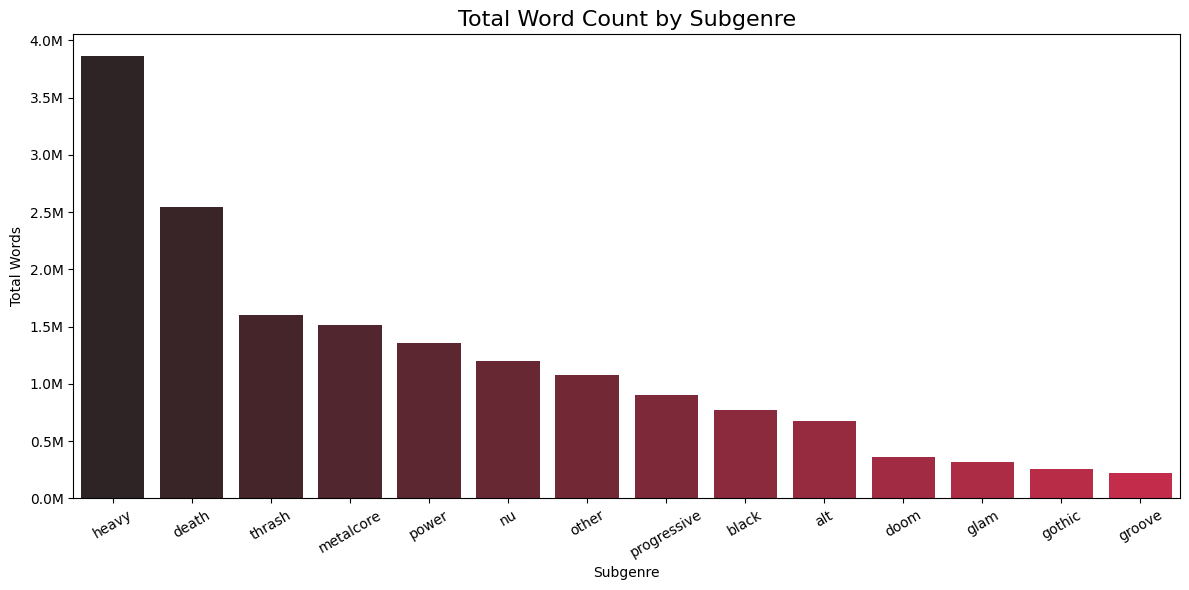

   subgenre  total_words percent_of_total
      heavy      3859933              23%
      death      2540850              15%
     thrash      1605285              10%
  metalcore      1511572               9%
      power      1355507               8%
         nu      1202608               7%
      other      1074455               6%
progressive       898786               5%
      black       767756               5%
        alt       678101               4%
       doom       359905               2%
       glam       318760               2%
     gothic       259562               2%
     groove       219268               1%


In [133]:
# Word count by subgenre

df_words = pd.read_sql("SELECT * FROM words", conn)

totals = {s: df_words[s].sum() for s in subgenres}
totals_df = pd.DataFrame(list(totals.items()), columns=['subgenre', 'total_words'])
totals_df = totals_df.sort_values('total_words', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=totals_df, x='subgenre', y='total_words', hue='subgenre', palette='dark:crimson', legend=False)
plt.title('Total Word Count by Subgenre', fontsize=16)
plt.xlabel('Subgenre')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.ylabel('Total Words')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

totals_df['percent_of_total'] = (totals_df['total_words'] / totals_df['total_words'].sum() * 100).round(0).astype(int).astype(str) + '%'
print(totals_df.to_string(index=False))

---

###  Country Representation

This dataset includes lyrics of bands from 45 countries. The United States leads by a significant margin, showing both the country's outsized influence on metal's development and the sheer size of its music scene. The next highest-represented countries are the UK, Sweden, and Germany, three countries whose influence on heavy metal is disproportionate to their size. This sets up an interesting per-capita question explored later in the findings.

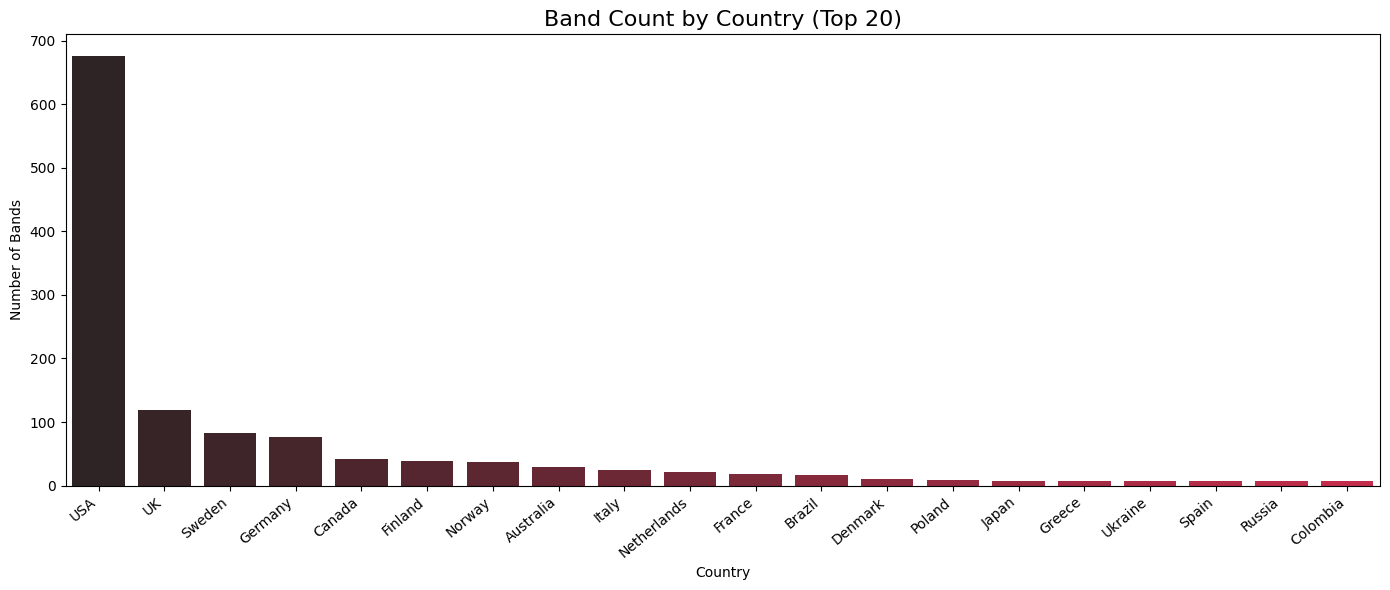

    country  band_count
        USA         676
         UK         119
     Sweden          82
    Germany          77
     Canada          42
    Finland          39
     Norway          37
  Australia          29
      Italy          24
Netherlands          22
     France          19
     Brazil          16
    Denmark          11
     Poland           9
      Japan           8
     Greece           8
    Ukraine           7
      Spain           7
     Russia           7
   Colombia           7


In [134]:
df_artists = pd.read_sql("SELECT country, COUNT(*) as band_count FROM artists GROUP BY country ORDER BY band_count DESC LIMIT 20", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_artists, x='country', y='band_count', hue='country', palette='dark:crimson', legend=False)
plt.title('Band Count by Country (Top 20)', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Bands')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(df_artists.to_string(index=False))

---

### Release Year Distribution

The corpus spans from 1968 to 2026. The earliest release included is the song *Helter Skelter* by The Beatles, and the first true "metal" album is Black Sabbath's self-titled album from 1970. Release count grows steadily through the 70s, 80s, and 90s before peaking in 2004, with 266. The decline starting in the mid-2010's is somewhat misleading; it likely reflects a selection bias towards the releases catalogued online and used in this project, not a decline in metal output. The album *Painkiller* (1990) by Judas Priest has had 36 years to earn its reputation; a 2022 release hasn't had that time yet.

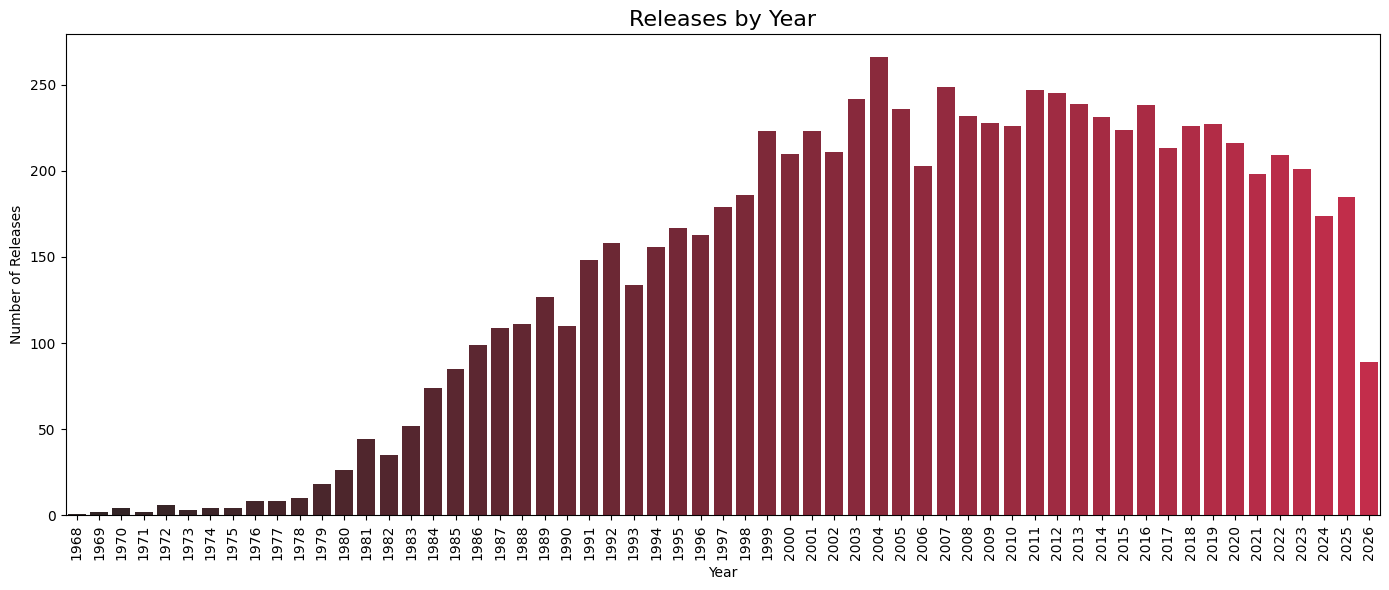

Earliest release: 1968
Most recent release: 2026
Most active year: 2004 (266 releases)


In [135]:
df_years = pd.read_sql("""
    SELECT year, COUNT(*) as release_count
    FROM releases
    WHERE year != 'Unknown'
    GROUP BY year
    ORDER BY year
""", conn)

df_years['year'] = pd.to_numeric(df_years['year'], errors='coerce')
df_years = df_years.dropna()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_years, x='year', y='release_count', hue='year', palette='dark:crimson', legend=False)
plt.title('Releases by Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Earliest release: {int(df_years['year'].min())}")
print(f"Most recent release: {int(df_years['year'].max())}")
print(f"Most active year: {int(df_years.loc[df_years['release_count'].idxmax(), 'year'])} ({df_years['release_count'].max()} releases)")

---

### Vocalist Gender Breakdown

95% of the releases in this dataset feature male vocalists; releases with female vocalists make up almost 5%, and bands with both male and female vocalists make up a fraction of a percent. Metal has always been a male-dominated music genre, and I made a deliberate effort to seek out bands with female vocalists to improve representation in this dataset. 

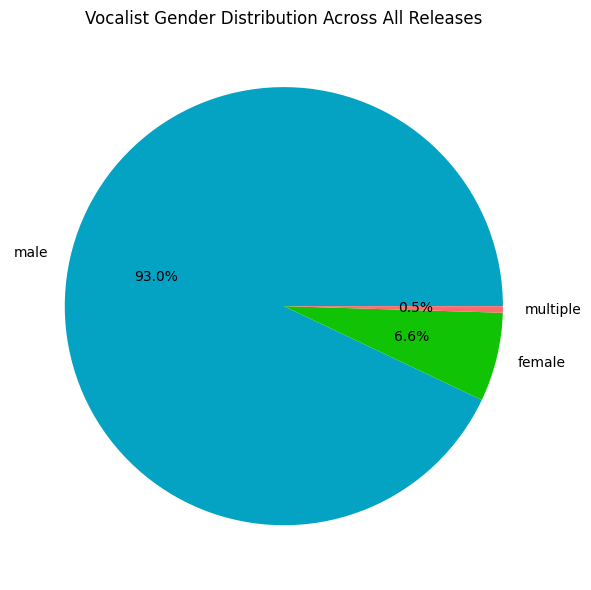

vocalist_gender  count
           male   7758
         female    548
       multiple     40


In [136]:
df_gender = pd.read_sql("""
    SELECT vocalist_gender, COUNT(*) as count
    FROM releases
    GROUP BY vocalist_gender
    ORDER BY count DESC
""", conn)

plt.figure(figsize=(8, 6))
plt.pie(df_gender['count'], labels=df_gender['vocalist_gender'], autopct='%1.1f%%', 
        colors=['#05a3c3', '#11c305', '#FF6B6B', '#FFB3B3'])
plt.title('Vocalist Gender Distribution Across All Releases', fontsize=12)
plt.tight_layout()
plt.show()

print(df_gender.to_string(index=False))

---

### Vocalist Gender by Subgenre

Which subgenres have the most female representation? For this question, I used Discogs' more specific subgenre classification system. 

Of the eight subgenres with the highest female vocalist representation, only one maps directly to one of the ten named subgenres in this analysis: Nu Metal. Symphonic Metal (48.3%) and Gothic Metal (44.8%) both significantly exceed Nu Metal's representation, but were collapsed into the broader categories of Power Metal and Other. 

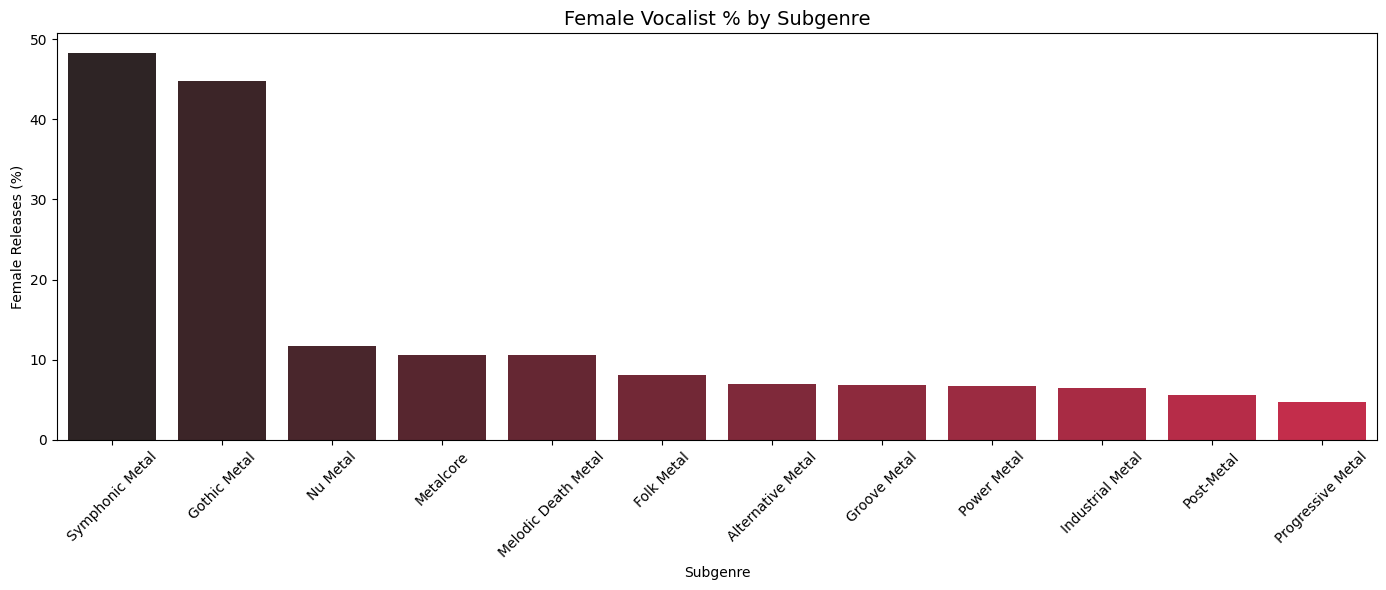

      subgenre_name  female_releases  male_releases  total_releases  female_pct
    Symphonic Metal              128            134             265        48.3
       Gothic Metal               69             85             154        44.8
           Nu Metal               55            414             469        11.7
          Metalcore               72            606             682        10.6
Melodic Death Metal               20            168             189        10.6
         Folk Metal               10            112             123         8.1
  Alternative Metal               19            251             271         7.0
       Groove Metal                6             82              88         6.8
        Power Metal               29            399             430         6.7
   Industrial Metal                5             72              77         6.5
         Post-Metal                4             67              71         5.6
  Progressive Metal               24    

In [156]:
df_gender_subgenre = pd.read_sql("""
    SELECT 
        subgenre_name,
        SUM(CASE WHEN vocalist_gender = 'female' THEN 1 ELSE 0 END) as female_releases,
        SUM(CASE WHEN vocalist_gender = 'male' THEN 1 ELSE 0 END) as male_releases,
        COUNT(*) as total_releases,
        ROUND(100.0 * SUM(CASE WHEN vocalist_gender = 'female' THEN 1 ELSE 0 END) / COUNT(*), 1) as female_pct
    FROM release_subgenres
    GROUP BY subgenre_name
    HAVING total_releases > 10
    AND subgenre_name LIKE '%Metal%' --This analysis uses Discogs' more granular subgenre list, so filtering for having "Metal" in the name prevents other genres like J-Pop or Ambient from appearing
    AND female_releases > 0
    ORDER BY female_pct DESC
    LIMIT 12
""", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_gender_subgenre, x='subgenre_name', y='female_pct',
            hue='subgenre_name', palette='dark:crimson', legend=False)
plt.title('Female Vocalist % by Subgenre', fontsize=14)
plt.xlabel('Subgenre')
plt.ylabel('Female Releases (%)')
plt.tick_params(axis='x', rotation=45)
#plt.axhline(y=df_gender_subgenre['female_pct'].mean(), color='gray', linestyle='--', label='Average')
#plt.legend()
plt.tight_layout()
plt.show()

print(df_gender_subgenre[['subgenre_name', 'female_releases', 'male_releases', 'total_releases', 'female_pct']].to_string(index=False))


---

The dataset is large, geographically and gender-diverse, and deliberately curated. With that context established, the real questions begin.

---

## Universal Metal Vocabulary

### The 10 Most Common Words in Metal Music

"What are the most common words used in metal?" was the question that started this whole project, and that is the first thing I want to answer.

,Word,Total
1,life,56955
2,world,38705
3,feel,35614
4,eyes,31603
5,love,30893
6,death,30653
7,die,29575
8,night,27777
9,nothing,27038
10,blood,27005


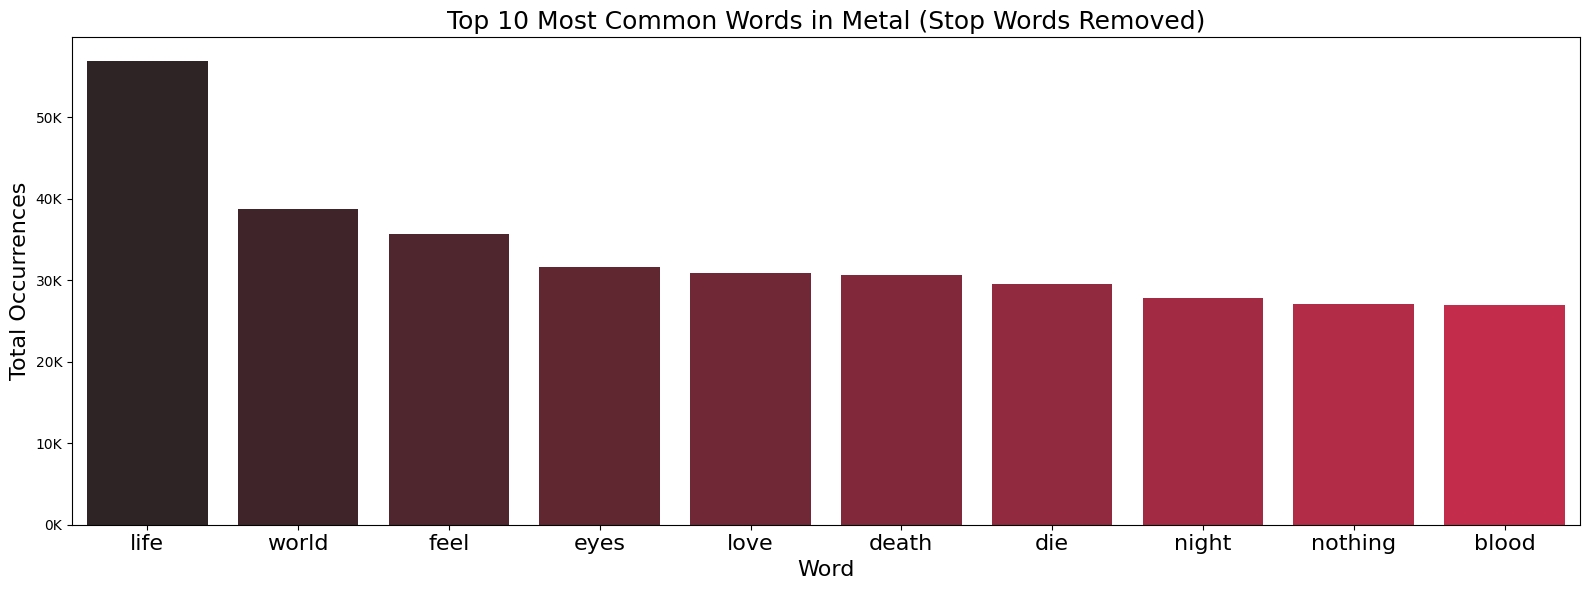

In [138]:
stop_words = {
    'the', 'and', 'to', 'of', 'a', 'in', 'i', 'you', 'my', 'is', 'it', 
    'me', 'for', 'on', 'we', 'no', 'that', 'will', 'your', 'all', 'this', 
    'are', 'be', 'with', 'not', 'but', 'so', 'as', 'have', 'from', 'or', 
    'an', 'at', 'by', 'they', 'do', 'if', 'was', 'their', 'our', 'its', 
    'been', 'has', 'her', 'him', 'his', 'she', 'he', 'can', 'what', 'when', 
    'there', 'than', 'more', 'up', 'out', 'am', 'into', 'us', 'would', 
    'who', 'which', 'had', 'were', 'one', 'about', 'just', 'now', 'like', 
    'how', 'know', 'get', 'go', 'come', 'see', 'time', 'way', 'could', 
    'make', 'take', 'through', 'over', 'back', 'down', 'then', 'only', 
    'some', 'other', 'new', 'also', 'two', 'may', 'after', 'where', 'much', 
    'before', 'here', 'away', 'still', 'even', 'never', 'those', 'them', 
    'these', 'such', 'own', 'too', 'very', 'well', 'did', 'should', 'while', 
    'off', 'again', 'same', 'upon', 'every', 'between', 'under', 'let',
    'don', 'got', 'say', 'said', 'til', 'cause', 'ain', 'gonna', 'wanna',
    'gotta', 'yeah', 'oh', 'ah', 'ha', 'na', 'la', 'da', 'wo', 'hey',
    'ooh', 'uh', 'whoa', 'mmm', 'huh', 'em', 'im', 've', 're', 'll',
    'i\'m', 'it\'s', 'you\'re', 'he\'s', 'she\'s', 'they\'re', 'we\'re', 
    'we\'ve', 'you\'ve', 'they\'ve', 'don\'t', 'i\'ll', 'he\'ll', 'she\'ll',
    'we\'ll', 'can\'t', 'i\'ve', 'there\'s', 'won\'t'
}

df_meaningful10 = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful10['total'] = df_meaningful10[subgenres].sum(axis=1)
df_meaningful10 = df_meaningful10.sort_values('total', ascending=False).head(10)

df_display = df_meaningful10[['word', 'total']].head(10).copy()
df_display.columns = ['Word', 'Total']
df_display = df_display.reset_index(drop=True)
df_display.index += 1
display(df_display)

plt.figure(figsize=(16, 6))
sns.barplot(data=df_meaningful10, x='word', y='total',
            hue='word', palette='dark:crimson', legend=False)
plt.title('Top 10 Most Common Words in Metal (Stop Words Removed)', fontsize=18)
plt.xlabel('Word', fontsize=16)
plt.ylabel('Total Occurrences', fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=16)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
plt.tight_layout()
plt.show()


#print("Top 10 most common meaningful words:")
#print()
#print(f"{'word':>5} {'total':>5}")
#print()
#print(df_meaningful[['word', 'total']].head(10).to_string(index=False, header=False))

These 10 words are so far above and beyond what I was hoping to find. Almost a decade ago, I made a silly little program to disprove someone else's claim (See README.md if you need context), and now the same question has led me to make this project and find this beautiful list. So much can be inferred from just these 10 words. 

First, and most obvious, the clear distinction between 5 positive-leaning words on top and 5 negative-leaning words on the bottom. Second, "life" and "love" appear more commonly than "death" and "die". And those are just surface-level findings. For example, you can use "life" in a positive or a negative context (i.e., "this life is beautiful" or "this life sucks"), but you can't really use "death" or "die" in a positive one. A sentiment analysis could reveal *how* "life" is really used and what metal music thinks about being alive.

This simple query answered my decade-old question and made me so excited to keep exploring. 

---

### Metal Vocabulary Word Cloud

From that top 10 word analysis, "life" and "love" coming before "death" and "die" made me curious about the overall sentiment of metal lyrics. To explore that, I used VADER, a sentiment analysis library, to assign a sentiment score to each word. The words are sized by usage frequency and colored by sentiment on a continuous scale: positive (green) to neutral (white) to negative (red). Stop words ("the", "and") are removed. I've applied a manual override to words like "blood" and "live", which appear as neutral in the VADER lexicon, but do carry meaning in this context.

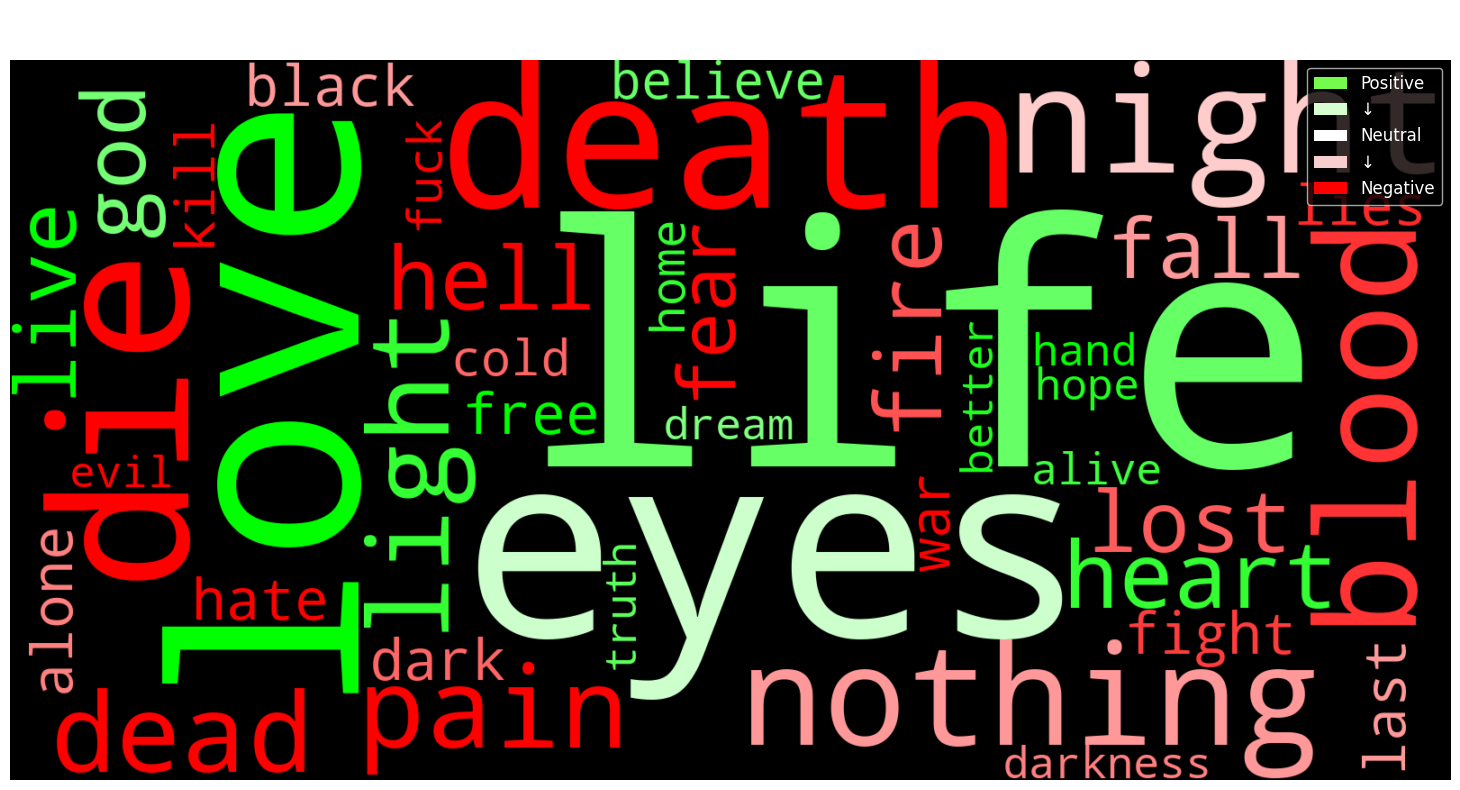

In [251]:
from wordcloud import WordCloud
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.colors as mcolors

sia = SentimentIntensityAnalyzer()

df_meaningful100 = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful100['total'] = df_meaningful100[subgenres].sum(axis=1)
df_meaningful100 = df_meaningful100.sort_values('total', ascending=False).head(100)

# Scores from -1.0 to 1.0, overriding VADER where it falls short
metal_overrides = {
    'life':     0.3, # mostly positive, but can be used in a negative context
    'night':   -0.1, # dark, a little atmospheric
    'nothing': -0.2, # pessimistic, but can be used in a positive context
    'eyes':     0.1, 
    'light':    0.4,
    'black':   -0.2,
    'blood':   -0.4, 
    'live':     0.6,
    'dark':    -0.3,
    'fall':    -0.2,
    'heart':    0.4,
    'believe':  0.3,
    'cold':    -0.3,
    'last':    -0.2,
    'home':     0.4   
}

def get_sentiment_color(word, font_size, position, orientation, random_state=None, **kwargs):
    if word.lower() in metal_overrides:
        score = metal_overrides[word.lower()]
    else:
        score = sia.polarity_scores(word)['compound']
    if score >= 0.05:
        clamped = min(score, 0.5) / 0.5
        intensity = int(clamped * 255)
        return f'rgb({255 - intensity}, 255, {255 - intensity})'
    elif score <= -0.05:
        clamped = min(abs(score), 0.5) / 0.5
        intensity = int(clamped * 255)
        return f'rgb(255, {255 - intensity}, {255 - intensity})'
    else:
        return 'rgb(255, 255, 255)'

def get_final_score(word):
    if word.lower() in metal_overrides:
        return metal_overrides[word.lower()]
    return sia.polarity_scores(word)['compound']

df_meaningful100['vader_score'] = df_meaningful100['word'].apply(get_final_score)
df_sentiment_filtered100 = df_meaningful100[df_meaningful100['vader_score'].abs() >= 0.1]

word_freq = dict(zip(df_sentiment_filtered100['word'], df_sentiment_filtered100['total']))

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=100,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Metal — Colored by Sentiment', fontsize=20, color='white', pad=20)

# Add a legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75fb4c', label='Positive'),
    Patch(facecolor='#d7fed0', label='↓'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='#f7cecd', label='↓'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='upper right', 
           facecolor='black', labelcolor='white', fontsize=12)

plt.tight_layout()
plt.show()

At a glance, the balance between negative to positive is nearly equal. Negative words are more numerous, but the most frequently used words tend to lean positive.

At the risk of being overcrowded, here is the same word cloud, populated with nearly 10 times the words for those who want to explore:

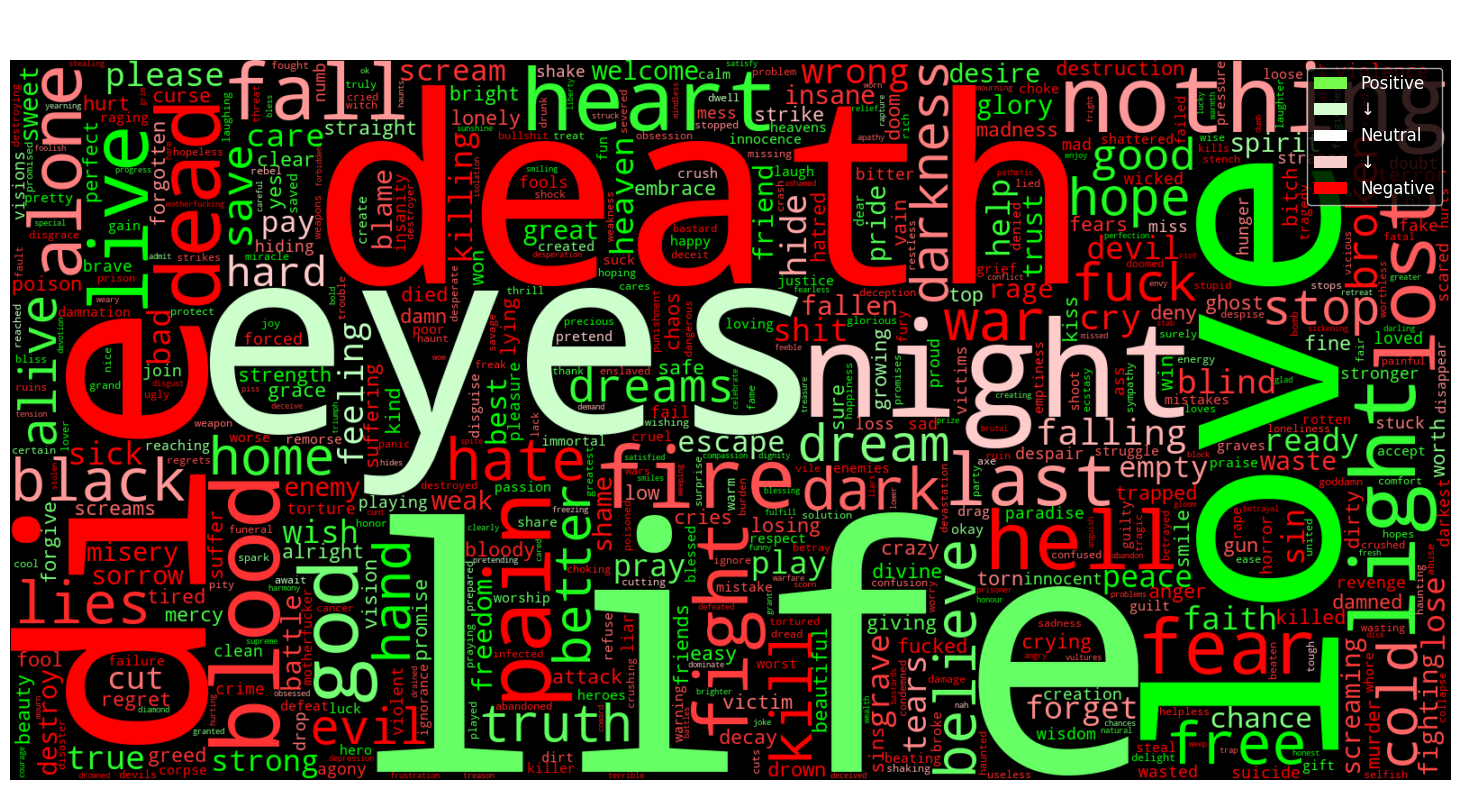

In [252]:
df_meaningful2000 = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful2000['total'] = df_meaningful2000[subgenres].sum(axis=1)
df_meaningful2000 = df_meaningful2000.sort_values('total', ascending=False).head(2500)

df_meaningful2000['vader_score'] = df_meaningful2000['word'].apply(get_final_score)
df_sentiment_filtered2000 = df_meaningful2000[df_meaningful2000['vader_score'].abs() >= 0.1]

word_freq = dict(zip(df_sentiment_filtered2000['word'], df_sentiment_filtered2000['total']))

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=800,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Metal — Colored by Sentiment', fontsize=20, color='white', pad=20)

# Add a legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75fb4c', label='Positive'),
    Patch(facecolor='#d7fed0', label='↓'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='#f7cecd', label='↓'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='upper right', 
           facecolor='black', labelcolor='white', fontsize=12)

plt.tight_layout()
plt.show()

As a completely unscientific aside, the average pixel color of the word cloud above is rgb(59, 53, 25). Because of how equally-matched red and green appear, I took 6 screenshots of it (Word clouds randomize placement each render), fed them into [matkl's Average Color App](https://matkl.github.io/average-color/), averaged them out, and the result was a red value of 59 and a green value of 53: a measly 11% difference between the two in favor of negative words. Again, completely unscientific. Word frequency, length, and character usage massively affect pixel count, but, yes, in this graph, red does land on top.

---

### Most Common Words by Subgenre

Because some subgenres are more equal than others in popularity and representation in this dataset, classic heavy metal could dominate the overall numbers. Maybe heavy metal talks about life a lot, but the rest don't. Let's break it down by subgenre:

In [141]:
results = {}
for subgenre in subgenres:
    df_sub = df_words[~df_words['word'].isin(stop_words)].copy()
    df_sub = df_sub[df_sub[subgenre] > 0]
    df_sub = df_sub.sort_values(subgenre, ascending=False).head(5)
    results[subgenre] = list(zip(df_sub['word'], df_sub[subgenre]))

rows = []
for subgenre in subgenres:
    if subgenre in results:
        words = [w for w, c in results[subgenre]]
        rows.append([subgenre] + words)

df_transposed = pd.DataFrame(rows, columns=['subgenre', '#1', '#2', '#3', '#4', '#5'])
df_transposed.index = range(1, len(df_transposed) + 1)

display(df_transposed.style.map(
    lambda x: 'font-weight: bold',
    subset=['#1']
))

,subgenre,#1,#2,#3,#4,#5
1,heavy,life,love,world,night,feel
2,thrash,life,death,world,die,blood
3,death,life,death,blood,world,dead
4,black,death,blood,life,night,black
5,groove,life,inside,death,nothing,eyes
6,progressive,life,world,eyes,light,feel
7,doom,life,eyes,world,love,death
8,power,life,world,night,light,fire
9,glam,love,baby,night,want,need
10,nu,life,feel,want,nothing,inside


11 of the 14 subgenres use 'life' as the most common meaningful word, and amazingly, death metal is among those 11. The three that don't are:\
**Black metal**, which uses 'death',\
**Glam metal**, which is apparently all about 'love', and\
**Alt metal**, which uses 'feel'.

The entire 5x14 table consists of only 19 unique words. The subgenre that sticks out the most is glam metal, with 'love', 'baby', 'night', 'want', and 'need'; two of which ('baby' and 'need') are entirely unique to glam metal. This reflects glam metal's commercial, radio-friendly image.

Subgenre-specific words among the top 5 used meaningful words include:\
**Glam metal**:   'Baby' and 'need'\
**Thrash metal**: 'Die'\
**Gothic metal**: 'Heart'\
**Death metal**:  'Dead'\
**Black metal**:  'Black'\
**Power metal**:  'Fire'

The shared stylistic origins between nu metal, alt metal, and metalcore show up in the data: all three share 'life' and 'feel' as their top two meaningful words, though not consistently in that order. These genres all took influence from late-'90s alternative rock, and the vocabulary reflects it.

---

### Most Unique Words By Subgenre

A more sophisticated approach would rank words by how disproportionately often they appear in one subgenre versus all others. That returns a messy (but funny) result, for reasons I'll discuss:

In [142]:
results_unique = {}
for subgenre in subgenres:
    df_sub = df_words[~df_words['word'].isin(stop_words)].copy()
    other_subgenres = [s for s in subgenres if s != subgenre]
    df_sub['other_total'] = df_sub[other_subgenres].sum(axis=1)
    df_sub['ratio'] = df_sub[subgenre] / (df_sub['other_total'] + 1)
    df_sub = df_sub[df_sub[subgenre] >= 20]
    df_sub = df_sub.sort_values('ratio', ascending=False).head(5)
    results_unique[subgenre] = list(zip(df_sub['word'], df_sub[subgenre]))

rows = []
for subgenre in subgenres:
    if subgenre in results_unique:
        words = [w for w, c in results_unique[subgenre]]
        rows.append([subgenre] + words)

df_transposed_unique = pd.DataFrame(rows, columns=['subgenre', '#1', '#2', '#3', '#4', '#5'])
df_transposed_unique.index = range(1, len(df_transposed_unique) + 1)

display(df_transposed_unique.style.map(
    lambda x: 'font-weight: bold',
    subset=['#1']
))

,subgenre,#1,#2,#3,#4,#5
1,heavy,piep,latten,nai,nanook,tico
2,thrash,nioj,mulambo,ooma,crippler,nevertrust
3,death,ouk,erebos,arra,amerika,virvum
4,black,lok'tar,saatanan,blashyrkh,nymphetamine,jumalan
5,groove,iou,babymetal,cowboy,volatile,sickest
6,progressive,livable,demolished,marigold,cantations,cygnus
7,doom,meddlesome,mantia,veem,ouvem,cheiram
8,power,nekron,liber,dargor,kunor,hargor
9,glam,kix,stevie,bop,feelgood,suzi
10,nu,stressin'out,uation,fittin,shari,rowboat


My analysis runs using raw frequency, meaning that 100 mentions of the word "the" in a song adds 100 ticks to that subgenre's "the" value. Similarly, **71** mentions of "piep", an onomatopoeia for a phone notification, in the song *Piep Piep Piep* by the German band The Butcher Sisters adds 71 ticks to heavy metal's "piep" row value. Other notable examples include:\
**99** mentions of 'pogo' in System of a Down's *Bounce*\
**77** mentions of 'spreck' in Infectious Groove's *Spreck*\
**66** mentions of 'barsch' in The Butcher Sisters' *Barsch*\
**35** mentions of 'feelgood' in Mötley Crüe's *Dr. Feelgood*\
**20** mentions of 'cigaro' in System of a Down's *Cigaro*\
**26** mentions of 'kix' in Kix's *Kix Are For Kids*

The subgenre-unique words table is *technically* accurate, but holds little meaningful data. To focus on meaningful vocabulary, the table below increases the minimum word count from 20 to 100 mentions before it is eligible to appear and manually removes non-English words, onomatopoeia, and blatant artifacts of raw frequency. A more rigorous fix is planned for V2: ranking words by range (how many distinct songs use a word), which would remove the need for manual curation.

This table contains explicit language and references to violence, reflective of common lyrical themes in extreme metal subgenres.

In [161]:
TOP_N = 5  # <- change this number and rerun the cell (Shift+Return) to see more words per subgenre

manual_remove = {
    'nai', 'cyco', 'je', 'olen', 'jeg', 'ved', 'fra', 'skal',
    'seg', 'meg', 'ov', 'dod', 'nar', 'nah', 'ba', 'dop',
    'ayy', 'ist', 'y', 'ur', 'eg', 'hann', 'sem', 'kan',
    'ingen', 'det', 'av', 'og', 'que', 'durch', 'nu', 'mig', 
    'allt', 'von', 'med', 'tid', 'ja', 'kun', 'alt', 'niin',
    'doch', 'ihr', 'vid', 'wenn', 'mina', 'som', 'ei', 'vil',
    'blod', 'var', 'om', 'liv', 'ett', 'fran', 'en', 'han',
    'och', 'har', 'att', 'jag', 'dich', 'din', 'pa', 'ut', 'er', 
    'skall', 'wir', 'uns', 'dir', 'sein', 'min', 'dar', 'sen',
    'mehr', 'oss', 'den', 'kuin', 'aus', 'vi', 'mitt', 'sie', 'jo',
    'lai', 'nicht', 'zu', 'auf', 'mein', 'ir', 'und', 'ser', 'ein', 
    'um', 'das', 'mir', 'mich', 'der', 'ar', 'dem', 'wie', 'sa',
    'du', 'mit', 'ich', 'fur', 'se', 'es', 'ay', 'ta', 'ni', 'dei',
    'k', 'gor', 'pas', 'il', 'che', 'di', 'o', 'de', 'to', 'v',
    'mot', 'ye', 'et', 'est', 'te', 'oooh', 'ad', 'e', 'tu', 'r', 
    'un', 'n', 'mu', 'x', 'le', 'l', 't', 'lo', 'mi', 'u', 'c',
    'ne', 'm', 'p', 'd', 'b', 'f', 's', 'les', 'mon', 'th'
}
# Although 'den' is a word in English, I believe its appearance as a uniquely black metal word 
# is most likely because it is also a Swedish, Danish, and Norwegian word that translates to 
# the much more common 'it' or 'that'.

results_unique = {}
for subgenre in subgenres:
    df_sub = df_words[
        ~df_words['word'].isin(stop_words) &
        ~df_words['word'].isin(manual_remove)
    ].copy()
    other_subgenres = [s for s in subgenres if s != subgenre]
    df_sub['other_total'] = df_sub[other_subgenres].sum(axis=1)
    df_sub['ratio'] = df_sub[subgenre] / (df_sub['other_total'] + 1)
    df_sub = df_sub[df_sub[subgenre] >= 100]
    df_sub = df_sub.sort_values('ratio', ascending=False).head(TOP_N)
    results_unique[subgenre] = list(zip(df_sub['word'], df_sub[subgenre]))

rows = []
for subgenre in subgenres:
    if subgenre in results_unique:
        words = [w for w, c in results_unique[subgenre]]
        words += [''] * (TOP_N - len(words)) #Displays empty instead of "None" if run out of words
        rows.append([subgenre] + words)

df_transposed_unique = pd.DataFrame(rows, columns = ['subgenre'] + [f'#{i}' for i in range(1, TOP_N + 1)])
df_transposed_unique.index = range(1, len(df_transposed_unique) + 1)

display(df_transposed_unique.style.map(
    lambda x: 'font-weight: bold',
    subset=['#1']
))

,subgenre,#1,#2,#3,#4,#5
1,heavy,babe,gypsy,london,rock,rocking
2,thrash,mosh,thrash,thrashing,beer,aggression
3,death,cadaver,butchery,fluids,innards,organs
4,black,inn,nocturnal,satanic,thou,satan
5,groove,test,pick,sick,does,shit
6,progressive,drifting,view,maze,ocean,cosmic
7,doom,lucifer,doom,arise,beauty,thee
8,power,pirate,dominus,sanctus,dwarves,rum
9,glam,blues,boys,girls,mama,baby
10,nu,jah,y'all,mic,rollin,pogo


Much better. With raw frequency artifacts removed, it provides a much better view of the unique vocabulary of each subgenre. It isn't perfect, however. The distinctive vocabulary isn't universal across each subgenre: power metal's list is topped by "pirate", which says more about a handful of pirate-themed bands in the genre than about power metal as a whole. Even so, the table does show meaningful data, and really does reinforce some stereotypes I've held about subgenres:

- **Nu metal** carried a rap influence into metal when it emerged, and with it came rap vocabulary. "y'all", 'mic', 'rollin' don't look like they belong with the rest of this list, and that's what made nu metal unique.
- **Thrash metal** likely got its name from the song *Metal Thrashing Mad* by Anthrax, so 'mosh', 'thrash', and 'thrashing' being the top three unique words for thrash metal is perfect.
- **Death metal** (Very broadly speaking) is shock rock taken to its natural extreme. The lyrics often don't matter; if they did, they would be enunciated, not growled. A band that I'm close with, Visceral Reaction, got their name from trying to find a name that would give people a "visceral reaction", so they cut out the middle man and just chose "Visceral Reaction".

This table has plenty more to explore, though how compelling it is likely depends on the reader's familiarity with the genre, so I'll leave further digging to the curious. If you'd like to see what comes after column 5, open the script above and adjust the variable at the top to however many columns you'd like to see.

Also, yeah, "pogo" is still in there. I'm not removing it.

---

### The Most "Metal" Words

Raw count can only get you so far. 10 years ago, my conclusion was that "the" was the most-used word in metal, but we can go further: What words appear disproportionately often in metal lyrics compared to their usage in everyday English?

To answer this question, I need a baseline for everyday word frequency. I'm using [SUBTLEX-US](https://www.ugent.be/pp/experimentele-psychologie/en/research/documents/subtlexus), a frequency database built by Ghent University, using 51 million words from American movie and TV show subtitles.

In [170]:
subtlex = pd.read_csv('SUBTLEXfreqPoS-sorted.csv')
subtlex = subtlex[['Word', 'SUBTLWF']].copy()
subtlex.columns = ['word', 'general_freq_per_million']
subtlex['word'] = subtlex['word'].str.lower()
subtlex = subtlex.groupby('word', as_index=False)['general_freq_per_million'].sum()
subtlex = subtlex.sort_values('general_freq_per_million', ascending=False)
subtlex.head()

,word,general_freq_per_million
60181,you,41857.12
26138,i,39971.16
53703,the,29449.18
54347,to,22677.84
45602,s,20731.39


With a general-English baseline loaded, I can now compare each word's frequency in my metal corpus against its frequency in everyday speech to find which words are disproportionately "metal".

In [259]:
TOP_N = 20 # <- change this number and rerun the cell to see more/fewer words

manual_remove_metal_words = {
    'og', 'och', 'av', 'ich', 'mot', 'det', 'na', 'var',
    'fra', 'sa', 'der', 'wir', 'dem', 'ist', 'mir', 'vi',
    'nar', 'du', 'ar', 'dei', 'das', 'att'
}

df_words['metal_total'] = df_words[subgenres].sum(axis=1)

total_words_corpus = df_words[subgenres].sum().sum()
df_words['metal_freq_per_million'] = df_words['metal_total'] / total_words_corpus * 1_000_000

df_metal_vs_general = df_words.merge(subtlex, on='word', how='inner')

df_metal_vs_general = df_metal_vs_general[df_metal_vs_general['general_freq_per_million'] > 0] # Just in case a word with a general frequency of 0 sneaks in
df_metal_vs_general = df_metal_vs_general[df_metal_vs_general['metal_total'] >= 750]
df_metal_vs_general = df_metal_vs_general[~df_metal_vs_general['word'].isin(manual_remove_metal_words)]

df_metal_vs_general['metal_ratio'] = (
    df_metal_vs_general['metal_freq_per_million'] / (df_metal_vs_general['general_freq_per_million'])
)

df_metal_vs_general = df_metal_vs_general.sort_values('metal_ratio', ascending=False)
df_metal_vs_general.head(TOP_N)[['word', 'metal_total', 'metal_freq_per_million', 'general_freq_per_million', 'metal_ratio']].style.map(
    lambda x: 'font-weight: bold',
    subset=['word', 'metal_ratio']
).format({
    'metal_freq_per_million': '{:.2f}',
    'general_freq_per_million': '{:.2f}',
    'metal_ratio': '{:.2f}',
})

,word,metal_total,metal_freq_per_million,general_freq_per_million,metal_ratio
6654,blackened,1504,90.32,0.31,291.35
2912,forevermore,1042,62.57,0.53,118.06
2229,legions,945,56.75,0.71,79.93
3247,unholy,1666,100.05,1.33,75.22
1173,decay,2450,147.13,2.06,71.42
896,darkened,904,54.29,0.78,69.60
1733,demise,1907,114.52,1.71,66.97
4346,abyss,1908,114.58,1.76,65.10
1465,fading,2653,159.32,2.45,65.03
1212,collide,918,55.13,0.92,59.92


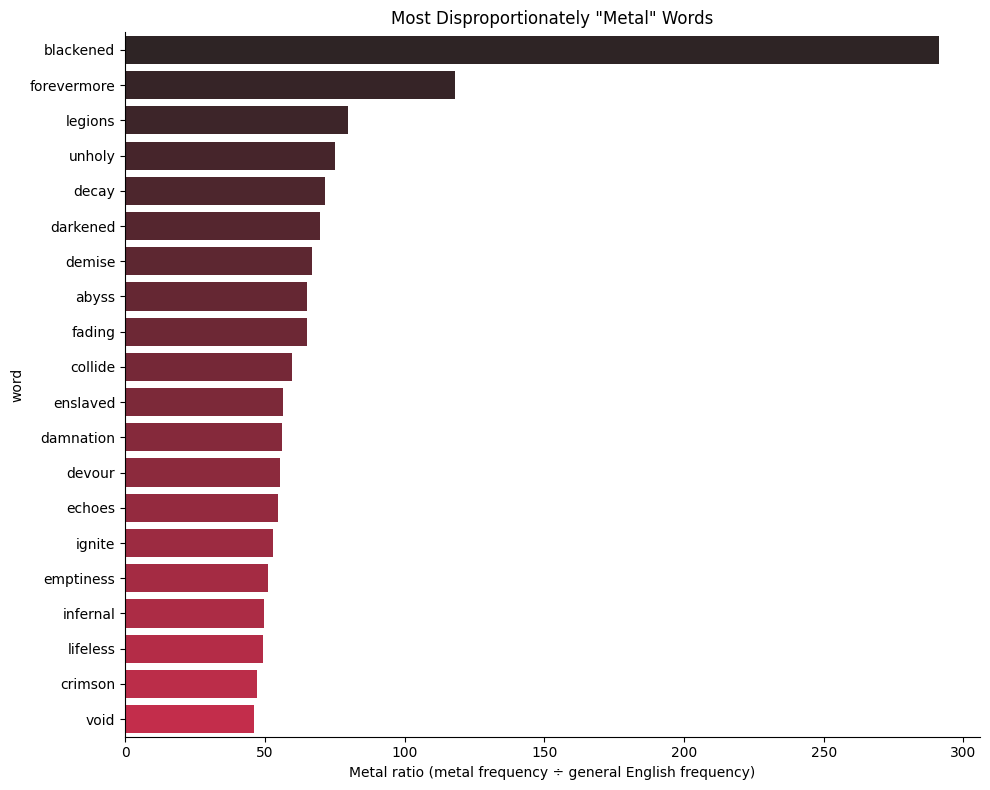

In [260]:
top_N_words = df_metal_vs_general.head(TOP_N).sort_values('metal_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_N_words, x='metal_ratio', y='word', palette='dark:crimson', ax=ax, hue='word', legend=False)
ax.set_xlabel('Metal ratio (metal frequency ÷ general English frequency)')
ax.set_title('Most Disproportionately "Metal" Words')
sns.despine()

plt.tight_layout()
plt.show()

This returns a list of words that I, as a metalhead, would like to say matches my own sense of the genre pretty well. It returns 'blackened' as the most disproportionately metal word, which I would agree with. 'Blackened' is such an essentially metal word that it transcends lyrics; a band that plays a non-black metal style but has strong black metal influence can be described as "blackened-". Blackened death metal, blackened crust punk, blackened thrash metal, etc.. 

Other words high on the list tend to cluster around themes of corruption (decay, fading, echoes, darkened), hellfire and damnation (unholy, abyss, damnation, ignite, legions, infernal), and nihilism (demise, emptiness, lifeless, void, abyss)

---

### Most Metal Vocabulary Word Cloud

I don't think I need to attach the sentiment lexicon to this one for you to understand the sentiment of these

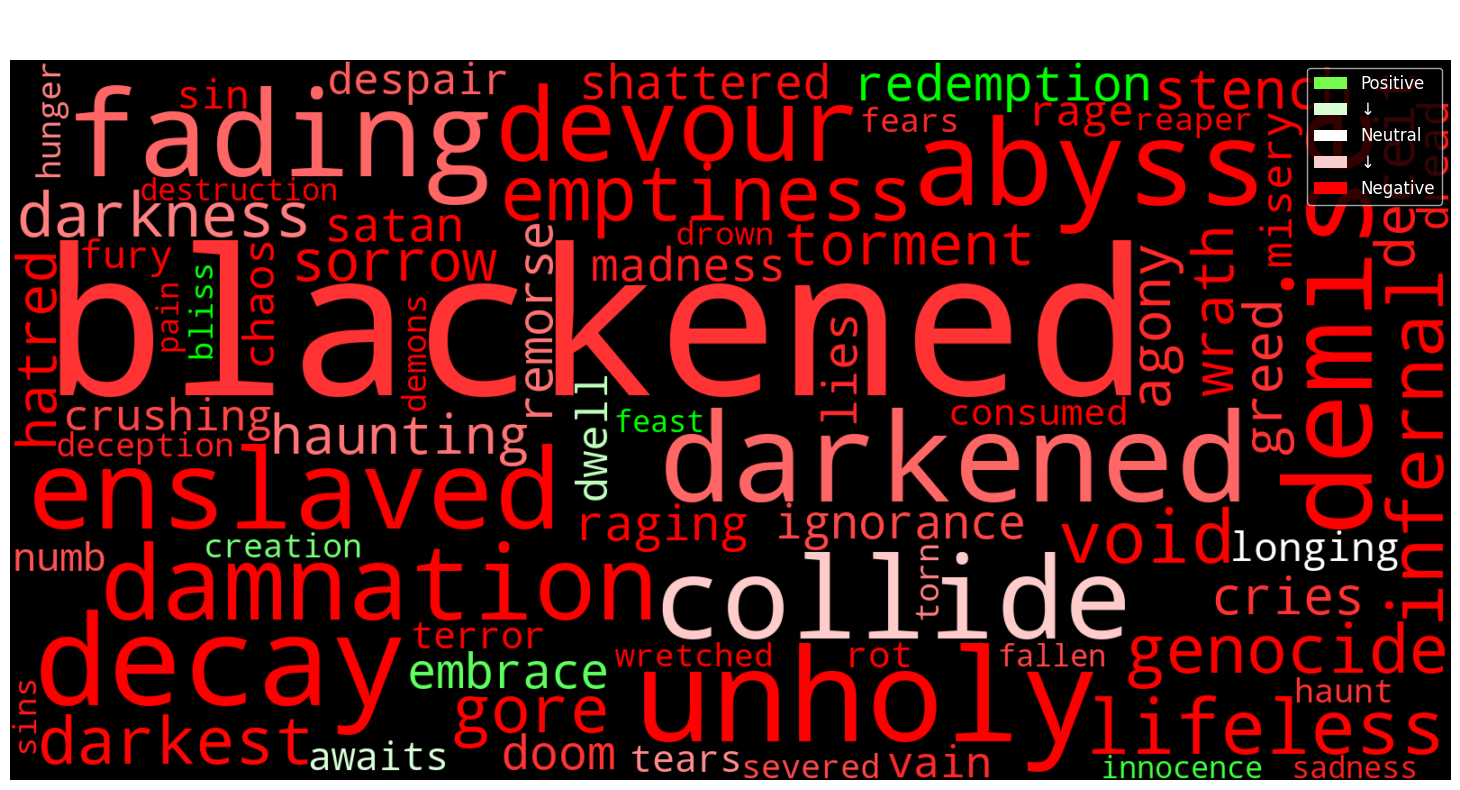

In [255]:
metal_overrides = {
    'life':     0.3, # mostly positive, but can be used in a negative context
    'night':   -0.1, # dark, a little atmospheric
    'nothing': -0.2, # pessimistic, but can be used in a positive context
    'eyes':     0.1, 
    'light':    0.4,
    'black':   -0.2,
    'blood':   -0.4, 
    'live':     0.6,
    'dark':    -0.3,
    'fall':    -0.2,
    'heart':    0.4,
    'believe':  0.3,
    'cold':    -0.3,
    'last':    -0.2,
    'home':     0.4,
    # Everything past here is for the most "metal" words
    'blackened': -0.4,
    'unholy':    -0.6, # strongly evil, religious
    'decay':     -0.5, # rot, deterioration
    'darkened':  -0.3,
    'demise':    -0.5, # death, downfall
    'abyss':     -0.5, # void, despair
    'fading':    -0.3, # decline
    'collide':   -0.1, 
    'enslaved':  -0.9, 
    'devour':    -0.5, # consumption, destruction
    'infernal':  -0.6, # hellish, evil
    'lifeless':  -0.7, # death, emptiness
    'void':      -0.5, # emptiness, nihilism
    'emptiness': -0.5, # hollow, despairing
    'satan':     -0.9, # don't get much worse than that
    'reaper':    -0.5, # 
    'feast':      0.5, # symbol of victory, indulgence
    'torment':   -0.7,
    'genocide':  -1.0, # okay, you can get a little worse than that
    'gore':      -0.5,
    'demons':    -0.6,
    'angels':     0.9,
    'wrath':     -0.7,
    'redemption': 0.6,
    'filth':     -0.6,
    'rot':       -0.5,
    'wretched':  -0.7,
    'nightmares':-0.7,
    'consumed':  -0.6,
    'plague':    -0.8
}

def has_sentiment_entry(word):
    """Returns True if the word has a real match in either metal_overrides
    or VADER's lexicon, rather than just defaulting to a neutral 0.0 score."""
    word_lower = word.lower()
    if word_lower in metal_overrides:
        return True
    # VADER's lexicon is exposed via sia.lexicon - a dict of word: score
    return word_lower in sia.lexicon

word_freq_metal_ratio_filtered = dict(
    zip(
        df_metal_vs_general[df_metal_vs_general['word'].apply(has_sentiment_entry)]['word'],
        df_metal_vs_general[df_metal_vs_general['word'].apply(has_sentiment_entry)]['metal_ratio']
    )
)

wordcloud_75_filtered = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=75,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq_metal_ratio_filtered)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud_75_filtered, interpolation='bilinear')
plt.axis('off')
plt.title('Most Disproportionately "Metal" Words — Colored by Sentiment', fontsize=20, color='white', pad=20)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75fb4c', label='Positive'),
    Patch(facecolor='#d7fed0', label='↓'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='#f7cecd', label='↓'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='upper right',
           facecolor='black', labelcolor='white', fontsize=12)
plt.tight_layout()
plt.show()

Not quite the equal sentiment split of the previous one.

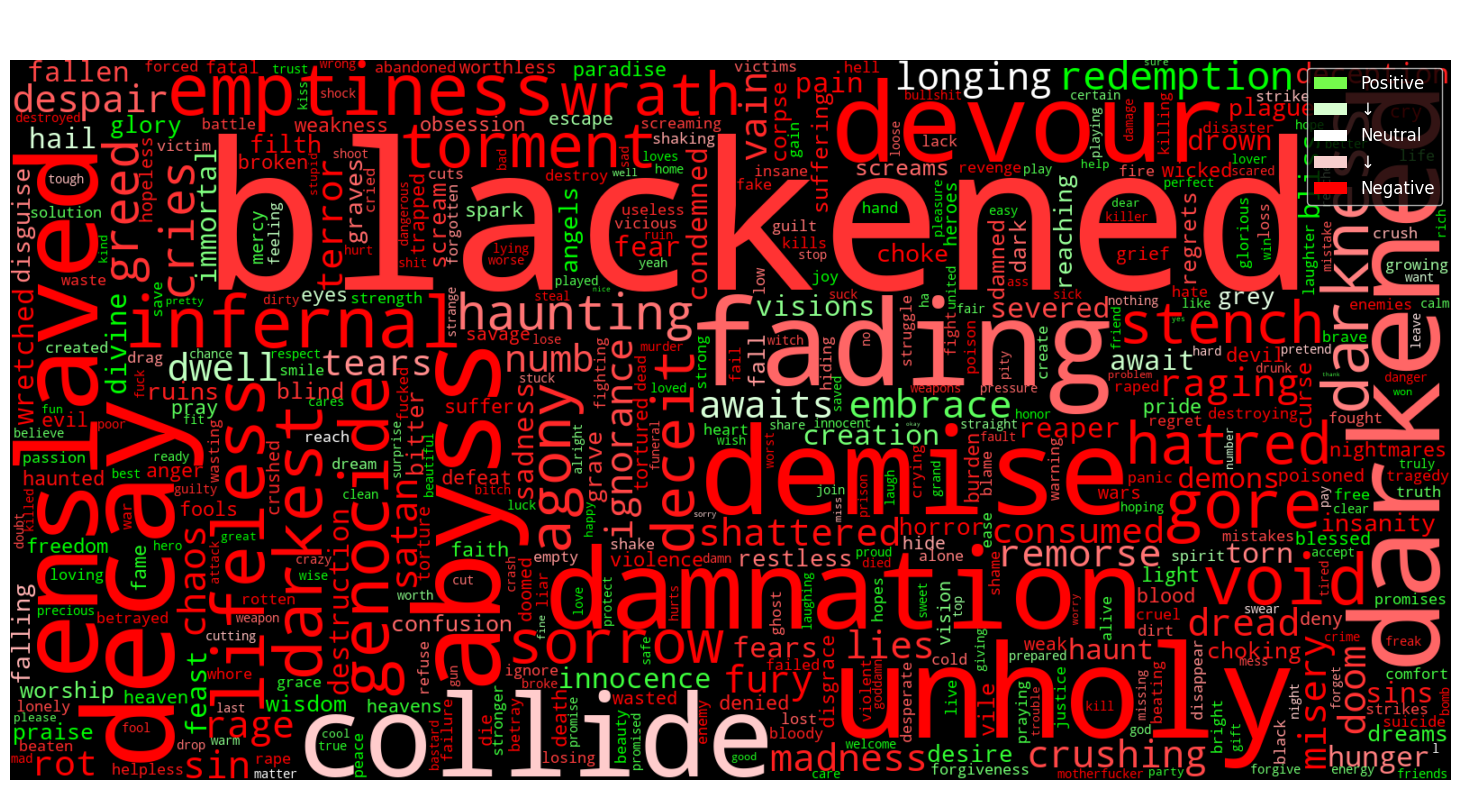

In [257]:
wordcloud_750_filtered = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=750,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq_metal_ratio_filtered)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud_750_filtered, interpolation='bilinear')
plt.axis('off')
plt.title('Most Disproportionately "Metal" Words — Colored by Sentiment', fontsize=20, color='white', pad=20)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75fb4c', label='Positive'),
    Patch(facecolor='#d7fed0', label='↓'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='#f7cecd', label='↓'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='upper right',
           facecolor='black', labelcolor='white', fontsize=12)
plt.tight_layout()
plt.show()

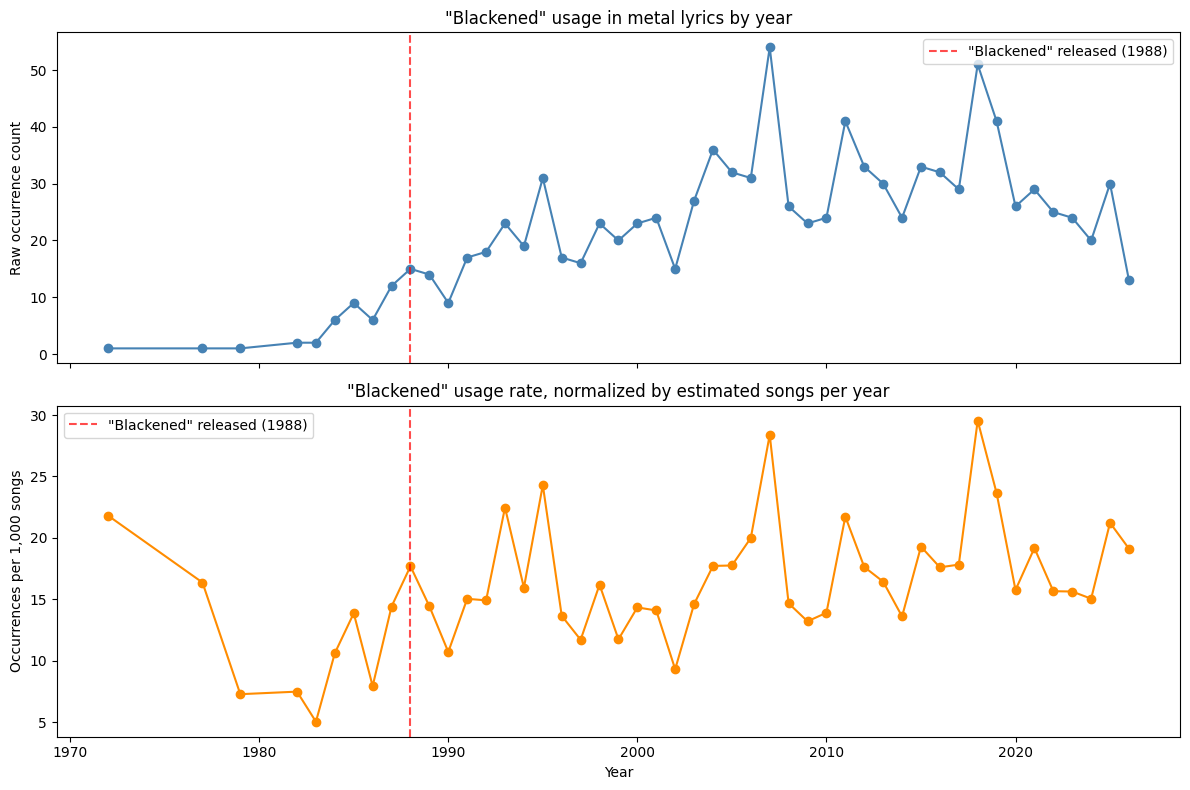

In [229]:
result = pd.read_csv('blackened_by_year.csv')

total_songs = 63214
total_releases = 8275
avg_songs_per_release = total_songs / total_releases

releases_per_year = pd.read_sql_query("""
    SELECT year, COUNT(*) AS release_count
    FROM releases
    WHERE year IS NOT NULL
    GROUP BY year
""", conn)

releases_per_year['estimated_songs'] = releases_per_year['release_count'] * avg_songs_per_release

# Merge with your blackened-by-year results and normalize
result = result.merge(releases_per_year[['year', 'estimated_songs']], on='year', how='left')
result['occurrence_per_1000_songs'] = result['occurrence'] / result['estimated_songs'] * 1000

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Raw occurrence count
axes[0].plot(result['year'], result['occurrence'], marker='o', color='steelblue')
axes[0].axvline(x=1988, color='red', linestyle='--', alpha=0.7, label='"Blackened" released (1988)')
axes[0].set_ylabel('Raw occurrence count')
axes[0].set_title('"Blackened" usage in metal lyrics by year')
axes[0].legend()

# Normalized rate
axes[1].plot(result['year'], result['occurrence_per_1000_songs'], marker='o', color='darkorange')
axes[1].axvline(x=1988, color='red', linestyle='--', alpha=0.7, label='"Blackened" released (1988)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Occurrences per 1,000 songs')
axes[1].set_title('"Blackened" usage rate, normalized by estimated songs per year')
axes[1].legend()

plt.tight_layout()
plt.show()

Methodology

- Specifics of the names "metal" vs. "heavy metal". 
- Why I chose the subgenres I did, what "other" is and what else can be included in the future